# 🧠 Aula 04: Estabilidade de Treinamento: Inicializações, Normalizações e Regularização

Bem-vindo(a) à **Aula 04** do curso de Redes Neurais Profundas da Graduação da Faculdade Infnet!

Nesta aula, investigaremos os fundamentos da estabilidade numérica e convergência de redes profundas:
por que redes profundas falham ou travam, como a simetria de pesos nulos destrói o aprendizado, como as inicializações **Xavier/Glorot** e **He/Kaiming** preservam a variância dos sinais, como **BatchNorm1d** e **LayerNorm** estabilizam distribuições internas e como o **Inverted Dropout** previne o sobreajuste (*overfitting*).

---

### 🎯 Objetivos de Aprendizagem
1. **Simetria de Pesos & Ponto de Sela**: Explicar analiticamente por que inicializar pesos com zero impede neurônios da mesma camada de aprenderem características distintas.
2. **Inicialização Científica de Pesos**: Calibrar variâncias com `torch.nn.init.xavier_uniform_` (para Tanh/Sigmoid) e `torch.nn.init.kaiming_normal_` (para ReLU/LeakyReLU).
3. **Normalização de Ativações no Mini-Batch (BatchNorm1d)**: Compreender o papel da normalização ao longo do batch, o cálculo de médias/variâncias móveis (*running stats*) e a alternância estrita entre `model.train()` e `model.eval()`.
4. **Normalização Intra-Amostra (LayerNorm)**: Distinguir a normalização independente de batches (`nn.LayerNorm`) da normalização de mini-batch.
5. **Regularização com Inverted Dropout**: Implementar `nn.Dropout` para quebrar co-adaptações de neurônios e controlar o gap entre loss de treino e validação.
6. **Simulação Prática e Análise de Fronteiras**: Visualizar o efeito de ativações e estabilização no dataset clássico Iris.

## 1. Configuração do Ambiente e Importações

Garantindo reprodutibilidade de experimentos com sementes (*seeds*) fixas.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyClassifier, DummyRegressor

# Fixar seeds para reproduzibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")


Utilizando dispositivo: cpu


## 2. Introdução: MLP Multicamadas no Dataset Iris

O dataset **Iris** contém 150 amostras de 3 espécies de flores (*setosa*, *versicolor*, *virginica*) com 4 atributos contínuos (comprimento e largura de sépala e pétala).

Por que precisamos de múltiplas camadas e funções de ativação?
Se removermos a função de ativação entre duas camadas lineares $W_1$ e $W_2$, o modelo equivale a uma única transformação linear $W_{equiv} = W_2 W_1$, incapaz de aprender fronteiras não-lineares!


In [ ]:
# Carregar dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Converter para Tensores do PyTorch
X_iris_t = torch.tensor(X_iris, dtype=torch.float32)
y_iris_t = torch.tensor(y_iris, dtype=torch.long)

# Definição do Perceptron de Múltiplas Camadas (MLP)
class MLPIris(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=8, output_dim=3, use_activation=True):
        super(MLPIris, self).__init__()
        self.use_activation = use_activation
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h = self.fc1(x)
        if self.use_activation:
            h = self.relu(h)
        out = self.fc2(h)
        return out

# Instanciar modelos com e sem função de ativação
model_with_act = MLPIris(use_activation=True).to(device)
model_no_act = MLPIris(use_activation=False).to(device)

print("Estrutura do Modelo MLP Iris:")
print(model_with_act)


Estrutura do Modelo MLP Iris:
MLPIris(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)


### Comparando Fronteiras de Decisão: Com vs. Sem Função de Ativação

Vamos treinar ambos os modelos no dataset Iris e visualizar o impacto da não-linearidade.


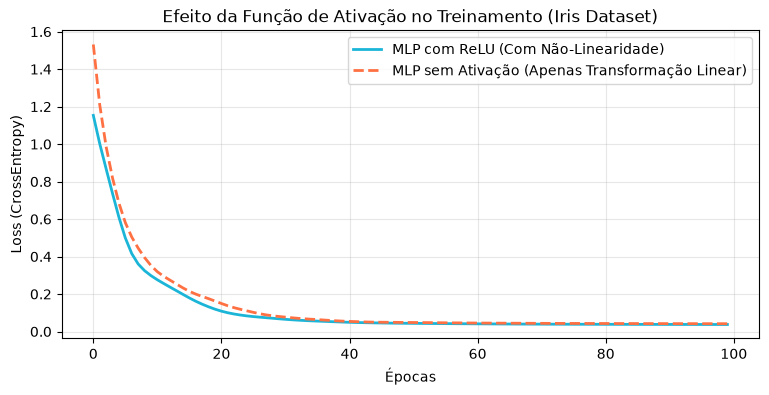

In [3]:
def train_simple_iris(model, X, y, epochs=100, lr=0.05):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X.to(device))
        loss = criterion(outputs, y.to(device))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return losses

losses_act = train_simple_iris(model_with_act, X_iris_t, y_iris_t)
losses_no_act = train_simple_iris(model_no_act, X_iris_t, y_iris_t)

plt.figure(figsize=(9, 4))
plt.plot(losses_act, label="MLP com ReLU (Com Não-Linearidade)", color="#1BB5D8", linewidth=2)
plt.plot(losses_no_act, label="MLP sem Ativação (Apenas Transformação Linear)", color="#FF7043", linestyle="--", linewidth=2)
plt.title("Efeito da Função de Ativação no Treinamento (Iris Dataset)")
plt.xlabel("Épocas")
plt.ylabel("Loss (CrossEntropy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Dataset da Indústria: Categorização de Transações Financeiras (Fintech)

Agora expandiremos nossa arquitetura MLP para um problema real de **Fintech SaaS**: categorização automática de transações bancárias para gestão financeira pessoal e empresarial.

Criaremos um dataset realista com atributos tabulares:
- `valor`: Valor monetário da transação (R$)
- `hora_dia`: Hora do dia (0 a 23h)
- `dia_semana`: Dia da semana (0 = Segunda, 6 = Domingo)
- `canal`: Canal da transação (0 = Cartão Físico, 1 = Pix, 2 = Boleto, 3 = Web/App)
- `score_confiabilidade_estabelecimento`: Indicador de risco/confiabilidade do comerciante
- **Target Multiclasse (`categoria`)**: 0 = Alimentação, 1 = Transporte, 2 = Saúde, 3 = Moradia, 4 = Lazer/Entretenimento
- **Target Regressão (`valor_estimado`)**: Estimativa/Predição contínua do gasto médio esperado


In [4]:
def generate_fintech_dataset(n_samples=2500, seed=42):
    np.random.seed(seed)
    
    # Gerar atributos sintéticos estruturados
    valor = np.random.exponential(scale=120, size=n_samples) + np.random.uniform(5, 50, size=n_samples)
    hora_dia = np.random.randint(0, 24, size=n_samples)
    dia_semana = np.random.randint(0, 7, size=n_samples)
    canal = np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.4, 0.35, 0.1, 0.15])
    score_estab = np.random.beta(a=5, b=2, size=n_samples) * 100
    
    # Regra com ruído para determinar a categoria de despesa (0: Alimentação, 1: Transporte, 2: Saúde, 3: Moradia, 4: Lazer)
    categoria = []
    for i in range(n_samples):
        if hora_dia[i] in [12, 13, 19, 20] and valor[i] < 150:
            cat = 0 # Alimentação
        elif hora_dia[i] in [7, 8, 17, 18] and valor[i] < 80:
            cat = 1 # Transporte
        elif valor[i] > 300 and score_estab[i] > 70:
            cat = 3 # Moradia / Contas
        elif hora_dia[i] >= 21 or (dia_semana[i] in [5, 6] and valor[i] > 100):
            cat = 4 # Lazer
        else:
            cat = 2 # Saúde / Outros
            
        # Adicionar 10% de ruído aleatório
        if np.random.rand() < 0.10:
            cat = np.random.randint(0, 5)
        categoria.append(cat)
        
    df = pd.DataFrame({
        "valor": valor,
        "hora_dia": hora_dia,
        "dia_semana": dia_semana,
        "canal": canal,
        "score_estab": score_estab,
        "categoria": categoria,
        "valor_log": np.log1p(valor)
    })
    return df

df_fintech = generate_fintech_dataset()
print("Amostra do Dataset de Transações Financeiras:")
print(df_fintech.head())
print("\nDistribuição das Categorias de Despesas:")
print(df_fintech['categoria'].value_counts())


Amostra do Dataset de Transações Financeiras:
        valor  hora_dia  dia_semana  canal  score_estab  categoria  valor_log
0   98.550522        18           3      1    75.721700          2   4.600665
1  400.618322         7           1      1    83.213974          3   5.995502
2  188.818286         6           2      3    61.245790          2   5.246067
3  157.575228        15           1      3    57.034283          2   5.066229
4   34.376338        18           6      0    40.576485          1   3.566043

Distribuição das Categorias de Despesas:
categoria
2    1283
4     593
0     271
3     190
1     163
Name: count, dtype: int64


### Construindo o `Dataset` e `DataLoader` no PyTorch

Separaremos o dataset em **Treino (70%)**, **Validação (15%)** e **Teste (15%)**.


In [5]:
class FintechDataset(Dataset):
    def __init__(self, X, y_class, y_reg):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_class = torch.tensor(y_class, dtype=torch.long)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y_class[idx], self.y_reg[idx]

# Atributos e Targets
features = ['valor', 'hora_dia', 'dia_semana', 'canal', 'score_estab']
X = df_fintech[features].values
y_class = df_fintech['categoria'].values
y_reg = df_fintech['valor_log'].values

# Split Treino (70%), Val (15%), Teste (15%)
X_train_val, X_test, y_c_train_val, y_c_test, y_r_train_val, y_r_test = train_test_split(
    X, y_class, y_reg, test_size=0.15, random_state=42, stratify=y_class
)
X_train, X_val, y_c_train, y_c_val, y_r_train, y_r_val = train_test_split(
    X_train_val, y_c_train_val, y_r_train_val, test_size=0.1765, random_state=42, stratify=y_c_train_val
) # 0.1765 * 0.85 = ~0.15

# Padronização dos atributos
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Datasets e DataLoaders
train_ds = FintechDataset(X_train_s, y_c_train, y_r_train)
val_ds = FintechDataset(X_val_s, y_c_val, y_r_val)
test_ds = FintechDataset(X_test_s, y_c_test, y_r_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Amostras Treino: {len(train_ds)}, Validação: {len(val_ds)}, Teste: {len(test_ds)}")


Amostras Treino: 1749, Validação: 376, Teste: 375


## 4. Arquitetura MLP Completa: Classificação vs. Regressão

Implementaremos uma classe `FintechMLP` modularizada com suporte a:
- Opções de funções de ativação (`ReLU`, `LeakyReLU`, `Tanh`, `Sigmoid`)
- Camadas de Normalização (`BatchNorm1d`, `LayerNorm`)
- Camadas de Regularização (`Dropout`)
- Cabeçotes de saída para **Classificação** (5 classes) ou **Regressão** (1 valor escalar)


In [6]:
class FintechMLP(nn.Module):
    def __init__(
        self, 
        input_dim=5, 
        hidden_dims=[64, 32], 
        output_dim=5, 
        task='classification', # 'classification' ou 'regression'
        activation='relu',     # 'relu', 'leaky_relu', 'tanh', 'sigmoid'
        norm_type=None,        # None, 'batchnorm', 'layernorm'
        dropout_rate=0.0
    ):
        super(FintechMLP, self).__init__()
        self.task = task
        
        # Seleção da função de ativação
        if activation == 'relu':
            act_cls = nn.ReLU
        elif activation == 'leaky_relu':
            act_cls = lambda: nn.LeakyReLU(0.1)
        elif activation == 'tanh':
            act_cls = nn.Tanh
        elif activation == 'sigmoid':
            act_cls = nn.Sigmoid
        else:
            raise ValueError(f"Ativação desconhecida: {activation}")
            
        layers = []
        in_d = input_dim
        
        for h_d in hidden_dims:
            layers.append(nn.Linear(in_d, h_d))
            
            # Adicionar normalização
            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_d))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_d))
                
            layers.append(act_cls())
            
            # Adicionar dropout
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
                
            in_d = h_d
            
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(in_d, output_dim)
        
    def forward(self, x):
        feat = self.backbone(x)
        out = self.head(feat)
        return out

# Exemplo de verificação da arquitetura
sample_model = FintechMLP(norm_type='batchnorm', dropout_rate=0.2)
print("Arquitetura da FintechMLP com BatchNorm e Dropout:")
print(sample_model)


Arquitetura da FintechMLP com BatchNorm e Dropout:
FintechMLP(
  (backbone): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (head): Linear(in_features=32, out_features=5, bias=True)
)


### Método de Inicialização de Pesos

Documentando o impacto da inicialização **Xavier/Glorot** e **He/Kaiming** comparadas à inicialização padrão do PyTorch.


In [7]:
def initialize_weights(model, init_type='default'):
    if init_type == 'default':
        return # PyTorch usa Kaiming Uniform por padrão em Linear
        
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier_uniform':
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif init_type == 'kaiming_normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif init_type == 'zeros':
                nn.init.zeros_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)


## 5. Loop de Treinamento Estável com Diagnóstico de Gradient Norms

Um treinamento profissional exige:
1. Cálculo e registro das **Normas de Gradiente** ($\|
abla_{\theta} L\|_2$) para diagnosticar Vanishing/Exploding Gradients.
2. Monitoramento contínuo das métricas em **Treino vs. Validação** para detectar Overfitting/Underfitting.
3. Salvamento de **Checkpoints (`state_dict`)** do melhor modelo.
4. Ajuste da taxa de aprendizado via **Learning Rate Scheduler**.


In [8]:
def train_model_stable(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler=None, 
    epochs=50, 
    writer=None, 
    save_path="best_model.pt",
    task='classification'
):
    model.to(device)
    best_val_loss = float('inf')
    history = {
        'train_loss': [], 'val_loss': [], 
        'grad_norms': [], 'lr': []
    }
    
    for epoch in range(1, epochs + 1):
        # --- Treinamento ---
        model.train()
        running_train_loss = 0.0
        total_grad_norm = 0.0
        n_batches = 0
        
        for X_b, y_c_b, y_r_b in train_loader:
            X_b = X_b.to(device)
            y_target = y_c_b.to(device) if task == 'classification' else y_r_b.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_target)
            loss.backward()
            
            # Calcular norma L2 total dos gradientes antes do optimizer.step()
            grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    grad_norm += param_norm.item() ** 2
            grad_norm = grad_norm ** 0.5
            total_grad_norm += grad_norm
            
            optimizer.step()
            running_train_loss += loss.item()
            n_batches += 1
            
        epoch_train_loss = running_train_loss / n_batches
        avg_grad_norm = total_grad_norm / n_batches
        current_lr = optimizer.param_groups[0]['lr']
        
        if scheduler is not None:
            scheduler.step()
            
        # --- Validação ---
        model.eval()
        running_val_loss = 0.0
        n_val_batches = 0
        with torch.no_grad():
            for X_b, y_c_b, y_r_b in val_loader:
                X_b = X_b.to(device)
                y_target = y_c_b.to(device) if task == 'classification' else y_r_b.to(device)
                outputs = model(X_b)
                v_loss = criterion(outputs, y_target)
                running_val_loss += v_loss.item()
                n_val_batches += 1
                
        epoch_val_loss = running_val_loss / n_val_batches
        
        # Guardar histórico
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['grad_norms'].append(avg_grad_norm)
        history['lr'].append(current_lr)
        
        # Registrar no TensorBoard se disponível
        if writer is not None:
            writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
            writer.add_scalar('Loss/Val', epoch_val_loss, epoch)
            writer.add_scalar('Diagnostics/GradNorm', avg_grad_norm, epoch)
            writer.add_scalar('Diagnostics/LearningRate', current_lr, epoch)
            
        # Salvar Checkpoint do Melhor Modelo
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            
    return history


## 6. Experimentos Empíricos & Análise de Diagnósticos

### Experimento 1: Comparativo de Inicialização de Pesos (Xavier vs. He vs. Padrão)

Vamos avaliar o impacto da inicialização nas curvas de perda do modelo de classificação.


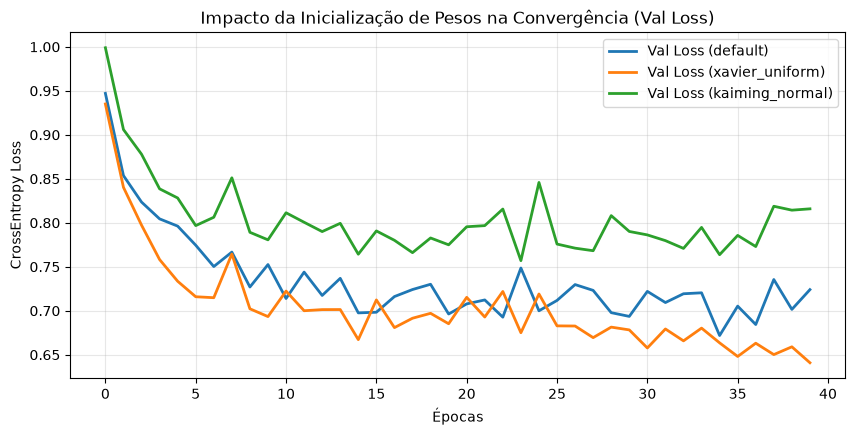

In [9]:
inits = ['default', 'xavier_uniform', 'kaiming_normal']
histories_init = {}

for init_name in inits:
    set_seed(42)
    model = FintechMLP(input_dim=5, hidden_dims=[64, 32], output_dim=5, task='classification')
    initialize_weights(model, init_type=init_name)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
    
    hist = train_model_stable(
        model, train_loader, val_loader, criterion, optimizer, 
        epochs=40, save_path=f"model_init_{init_name}.pt", task='classification'
    )
    histories_init[init_name] = hist

plt.figure(figsize=(10, 4.5))
for init_name, hist in histories_init.items():
    plt.plot(hist['val_loss'], label=f"Val Loss ({init_name})", linewidth=2)
plt.title("Impacto da Inicialização de Pesos na Convergência (Val Loss)")
plt.xlabel("Épocas")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Experimento 2: Normalização (BatchNorm1d vs. LayerNorm) e Regularização (Dropout)

Investigando o controle de instabilidade e a prevenção de overfitting.


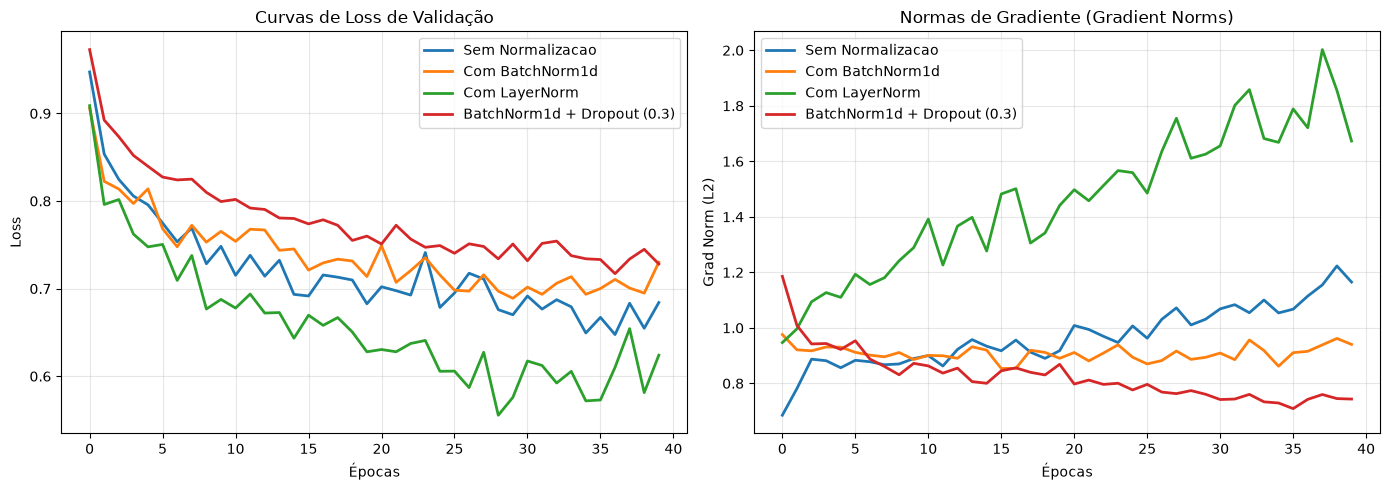

In [10]:
configs = {
    'Sem Normalizacao': {'norm_type': None, 'dropout_rate': 0.0},
    'Com BatchNorm1d': {'norm_type': 'batchnorm', 'dropout_rate': 0.0},
    'Com LayerNorm': {'norm_type': 'layernorm', 'dropout_rate': 0.0},
    'BatchNorm1d + Dropout (0.3)': {'norm_type': 'batchnorm', 'dropout_rate': 0.3}
}

histories_norm = {}

for cfg_name, cfg in configs.items():
    set_seed(42)
    model = FintechMLP(
        input_dim=5, hidden_dims=[64, 32], output_dim=5, 
        task='classification', norm_type=cfg['norm_type'], dropout_rate=cfg['dropout_rate']
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.005)
    
    clean_name = cfg_name.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')
    hist = train_model_stable(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=40, save_path=f"model_{clean_name}.pt", task='classification'
    )
    histories_norm[cfg_name] = hist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Val Loss
for name, hist in histories_norm.items():
    axes[0].plot(hist['val_loss'], label=name, linewidth=2)
axes[0].set_title("Curvas de Loss de Validação")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Gradient Norms
for name, hist in histories_norm.items():
    axes[1].plot(hist['grad_norms'], label=name, linewidth=2)
axes[1].set_title("Normas de Gradiente (Gradient Norms)")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Grad Norm (L2)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 🏆 Conclusão e Resumo Pedagógico da Aula 04

Nesta aula, desvendamos os três pilares que sustentam a estabilidade do Deep Learning moderno:
1. **Inicialização Científica**: Xavier para ativações lineares/simétricas (Tanh/Sigmoid) e Kaiming He para ativadores com corte em zero (ReLU).
2. **Normalização de Camadas**: `BatchNorm1d` estabiliza o fluxo de sinais e acelera a convergência, enquanto `LayerNorm` normaliza intra-amostra.
3. **Regularização**: O `Dropout` zera neurônios aleatoriamente no treino e reescala por $1/(1-p)$ para eliminar a necessidade de ajuste em inferência.

Na **Aula 05**, avançaremos para o motor de otimização: algoritmos Adam/AdamW, Learning Rate Schedulers, diagnóstico visual de gradientes e integração profissional com o **TensorBoard**!